In [8]:
import pandas as pd

file_path = "debutanizer_data.txt"

# Column names
columns = ["u1", "u2", "u3", "u4", "u5", "u6", "u7", "y"]

# Read and clean 
data = []
with open(file_path, "r") as f:
    for line in f:
        # Split by whitespace
        parts = line.strip().split()
        # Keep only lines with exactly 8 numbers
        if len(parts) == 8:
            try:
                numbers = [float(x) for x in parts]
                data.append(numbers)
            except ValueError:
                continue  # skip any non-numeric line

# Convert to DataFrame
df = pd.DataFrame(data, columns=columns)

# Save to Excel
output_file = "debutanizer_data_clean.xlsx"
df.to_excel(output_file, index=False)

print(f"✅ Cleaned data with {len(df)} rows saved to {output_file}")


✅ Cleaned data with 2394 rows saved to debutanizer_data_clean.xlsx


In [18]:
    pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Loading cleaned Excel file
file_path = "debutanizer_data_clean.xlsx"
df = pd.read_excel(file_path)

# Separate input (X) and output (y)
X = df.drop(columns=["y"])   # all u1..u7
y = df["y"]                  # output column

# Splitiing into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Optionally combine back into train/test DataFrames
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Saving to Excel
train_df.to_excel("train_data.xlsx", index=False)
test_df.to_excel("test_data.xlsx", index=False)

print(f"✅ Training data: {train_df.shape[0]} rows saved to train_data.xlsx")
print(f"✅ Testing data:  {test_df.shape[0]} rows saved to test_data.xlsx")


✅ Training data: 1675 rows saved to train_data.xlsx
✅ Testing data:  719 rows saved to test_data.xlsx


In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the train and test Excel files
train_df = pd.read_excel("train_data.xlsx")
test_df = pd.read_excel("test_data.xlsx")

# Separate features (u1..u7) and target (y)
X_train = train_df.drop(columns=["y"])
y_train = train_df["y"]

X_test = test_df.drop(columns=["y"])
y_test = test_df["y"]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training features only
X_train_scaled = scaler.fit_transform(X_train)

# Transform test features using same scaler
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with same column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Combine scaled features with original target
train_scaled_df = pd.concat([X_train_scaled, y_train], axis=1)
test_scaled_df = pd.concat([X_test_scaled, y_test], axis=1)

# Save to Excel
train_scaled_df.to_excel("train_data_scaled.xlsx", index=False)
test_scaled_df.to_excel("test_data_scaled.xlsx", index=False)

print("✅ Scaled training and test data saved as train_data_scaled.xlsx and test_data_scaled.xlsx")


✅ Scaled training and test data saved as train_data_scaled.xlsx and test_data_scaled.xlsx


In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Correlation filtering ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)

X = X.drop(columns=to_drop)
print("✅ Remaining features after correlation filtering:", list(X.columns))

# --- STEP 3: Forward selection ---
selected_features = []
remaining_features = list(X.columns)
current_score = np.inf  # SSE starts high

improvement_threshold = 1e-5  # stopping criteria

print("\n🔍 Starting forward selection...")

while remaining_features:
    best_feature = None
    best_sse = current_score

    for feature in remaining_features:
        trial_features = selected_features + [feature]
        model = LinearRegression()
        model.fit(X[trial_features], y)
        predictions = model.predict(X[trial_features])
        sse = mean_squared_error(y, predictions) * len(y)  # SSE

        if sse < best_sse:
            best_sse = sse
            best_feature = feature

    improvement = current_score - best_sse
    if best_feature is not None and improvement > improvement_threshold:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        current_score = best_sse
        print(f"➕ Added feature: {best_feature}, SSE improvement: {improvement:.6f}")
    else:
        print("⏹ No significant improvement — stopping selection.")
        break

print("\n🏆 Final selected features:", selected_features)


🚫 Dropped due to high correlation: ['u7']
✅ Remaining features after correlation filtering: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']

🔍 Starting forward selection...
➕ Added feature: u3, SSE improvement: inf
➕ Added feature: u5, SSE improvement: 2.480771
➕ Added feature: u1, SSE improvement: 1.636849
➕ Added feature: u4, SSE improvement: 2.268433
➕ Added feature: u2, SSE improvement: 0.739867
➕ Added feature: u6, SSE improvement: 0.167707

🏆 Final selected features: ['u3', 'u5', 'u1', 'u4', 'u2', 'u6']


In [29]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Correlation filtering ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)

X = X.drop(columns=to_drop)
print("✅ Remaining features after correlation filtering:", list(X.columns))

# --- STEP 3: Forward selection with AIC ---
selected_features = []
remaining_features = list(X.columns)

def compute_aic(n, sse, num_params):
    """Compute Akaike Information Criterion (AIC)."""
    aic = n * np.log(sse / n) + 2 * num_params
    return aic

current_aic = np.inf
improvement_threshold = 1e-4  # stopping criteria

print("\n🔍 Starting forward selection with AIC...")

while remaining_features:
    best_feature = None
    best_aic = current_aic

    for feature in remaining_features:
        trial_features = selected_features + [feature]
        model = LinearRegression()
        model.fit(X[trial_features], y)
        predictions = model.predict(X[trial_features])
        sse = mean_squared_error(y, predictions) * len(y)  # SSE
        aic = compute_aic(len(y), sse, len(trial_features) + 1)  # +1 for intercept

        if aic < best_aic:
            best_aic = aic
            best_feature = feature

    improvement = current_aic - best_aic
    if best_feature is not None and improvement > improvement_threshold:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        current_aic = best_aic
        print(f"➕ Added feature: {best_feature}, AIC improvement: {improvement:.6f}")
    else:
        print("⏹ No significant AIC improvement — stopping selection.")
        break

print("\n🏆 Final selected features:", selected_features)


🚫 Dropped due to high correlation: ['u7']
✅ Remaining features after correlation filtering: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']

🔍 Starting forward selection with AIC...
➕ Added feature: u3, AIC improvement: inf
➕ Added feature: u5, AIC improvement: 104.268454
➕ Added feature: u1, AIC improvement: 72.000375
➕ Added feature: u4, AIC improvement: 106.278326
➕ Added feature: u2, AIC improvement: 34.885462
➕ Added feature: u6, AIC improvement: 6.475016

🏆 Final selected features: ['u3', 'u5', 'u1', 'u4', 'u2', 'u6']


In [33]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [35]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


🚫 Dropped due to high correlation: ['u7']
✅ Remaining features after correlation filtering: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']

🔍 Starting forward selection with AIC...
➕ Added feature: u3, AIC improvement: inf
➕ Added feature: u5, AIC improvement: 104.268454
➕ Added feature: u1, AIC improvement: 72.000375
➕ Added feature: u4, AIC improvement: 106.278326
➕ Added feature: u2, AIC improvement: 34.885462
➕ Added feature: u6, AIC improvement: 6.475016

🏆 Final selected features: ['u3', 'u5', 'u1', 'u4', 'u2', 'u6']


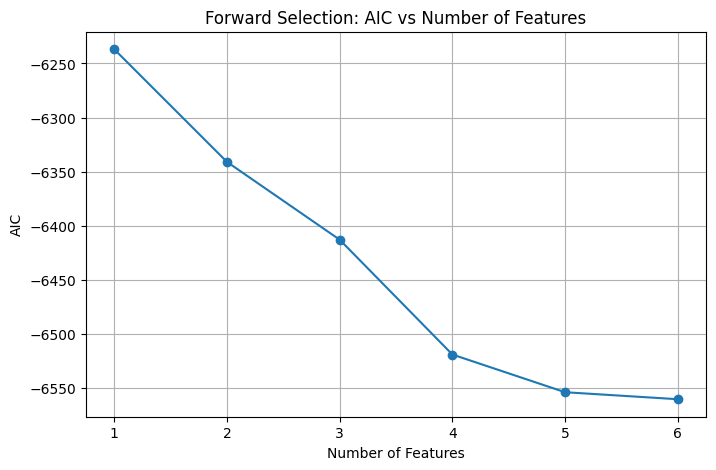

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Correlation filtering ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)

X = X.drop(columns=to_drop)
print("✅ Remaining features after correlation filtering:", list(X.columns))

# --- STEP 3: Forward selection with AIC ---
selected_features = []
remaining_features = list(X.columns)
aic_history = []

def compute_aic(n, sse, num_params):
    """Compute Akaike Information Criterion (AIC)."""
    return n * np.log(sse / n) + 2 * num_params

current_aic = np.inf
improvement_threshold = 1e-4

print("\n🔍 Starting forward selection with AIC...")

while remaining_features:
    best_feature = None
    best_aic = current_aic

    for feature in remaining_features:
        trial_features = selected_features + [feature]
        model = LinearRegression()
        model.fit(X[trial_features], y)
        predictions = model.predict(X[trial_features])
        sse = mean_squared_error(y, predictions) * len(y)  # SSE
        aic = compute_aic(len(y), sse, len(trial_features) + 1)  # +1 for intercept

        if aic < best_aic:
            best_aic = aic
            best_feature = feature

    improvement = current_aic - best_aic
    if best_feature is not None and improvement > improvement_threshold:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        current_aic = best_aic
        aic_history.append(current_aic)
        print(f"➕ Added feature: {best_feature}, AIC improvement: {improvement:.6f}")
    else:
        print("⏹ No significant AIC improvement — stopping selection.")
        break

print("\n🏆 Final selected features:", selected_features)

# --- STEP 4: Plot AIC vs. number of features ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(aic_history) + 1), aic_history, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("AIC")
plt.title("Forward Selection: AIC vs Number of Features")
plt.grid(True)
plt.show()


In [38]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Correlation filtering ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)

X = X.drop(columns=to_drop)
print("✅ Remaining features after correlation filtering:", list(X.columns))

# --- STEP 3: Standardize features (important for Lasso) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 4: LassoCV for hyperparameter tuning ---
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"🔍 Optimal α found by cross-validation: {lasso_cv.alpha_:.6f}")

# --- STEP 5: Features selected by Lasso (non-zero coefficients) ---
coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = coef[coef != 0].index.tolist()

print("\n🏆 Features selected by Lasso Regression:", selected_features)

# Optional: Show coefficients
print("\nFeature coefficients:")
print(coef.sort_values(ascending=False))


🚫 Dropped due to high correlation: ['u7']
✅ Remaining features after correlation filtering: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']
🔍 Optimal α found by cross-validation: 0.000272

🏆 Features selected by Lasso Regression: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']

Feature coefficients:
u1    0.046738
u4    0.036354
u6    0.016012
u2   -0.023560
u3   -0.035657
u5   -0.064961
dtype: float64


🚫 Dropped due to high correlation: ['u7']
✅ Remaining features after correlation filtering: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']
🔍 Optimal α found by cross-validation: 0.000272

🏆 Features selected by Lasso Regression: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']


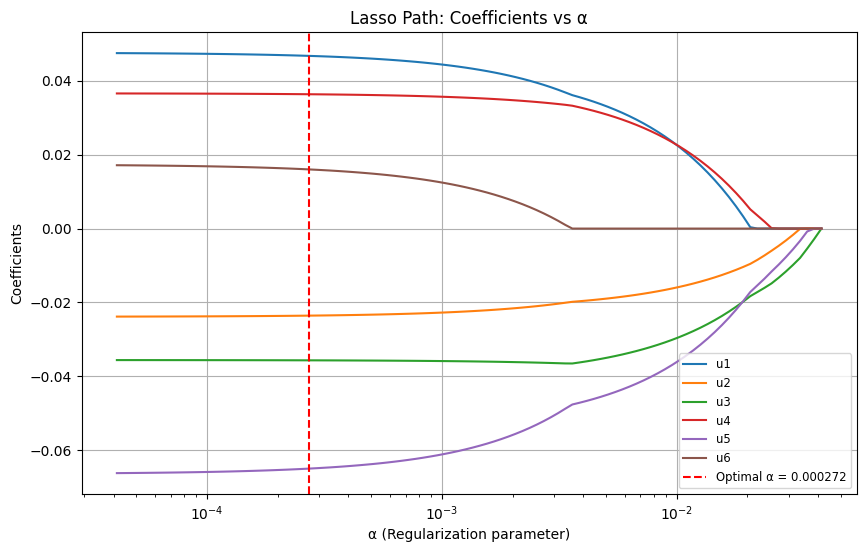

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Correlation filtering ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)

X = X.drop(columns=to_drop)
print("✅ Remaining features after correlation filtering:", list(X.columns))

# --- STEP 3: Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 4: LassoCV ---
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"🔍 Optimal α found by cross-validation: {lasso_cv.alpha_:.6f}")

# --- STEP 5: Selected features ---
coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = coef[coef != 0].index.tolist()

print("\n🏆 Features selected by Lasso Regression:", selected_features)

# --- STEP 6: Lasso coefficient path plot ---
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y)

plt.figure(figsize=(10, 6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=X.columns[i])

plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f"Optimal α = {lasso_cv.alpha_:.6f}")
plt.xlabel("α (Regularization parameter)")
plt.ylabel("Coefficients")
plt.title("Lasso Path: Coefficients vs α")
plt.xscale('log')
plt.legend(loc="best", fontsize="small")
plt.grid(True)
plt.show()


🚫 Dropped due to high correlation: ['u7']
✅ Remaining features after correlation filtering: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']
🔍 Optimal α found by cross-validation: 0.000272

🏆 Features selected by Lasso Regression: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']


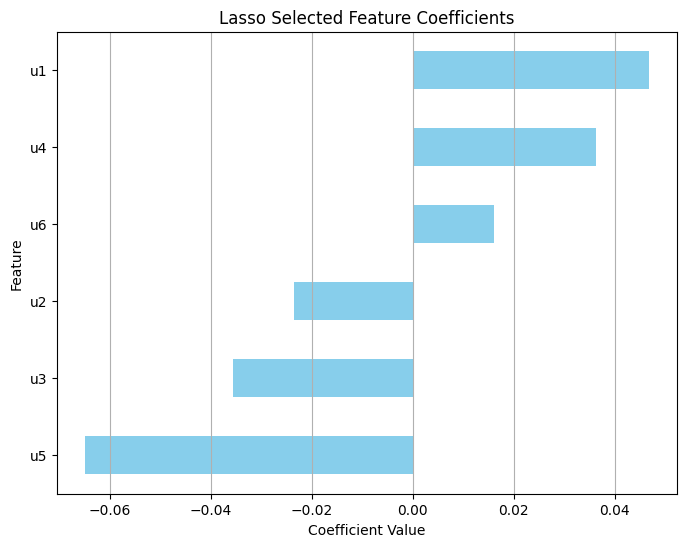

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Correlation filtering ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)

X = X.drop(columns=to_drop)
print("✅ Remaining features after correlation filtering:", list(X.columns))

# --- STEP 3: Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 4: LassoCV ---
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"🔍 Optimal α found by cross-validation: {lasso_cv.alpha_:.6f}")

# --- STEP 5: Selected features ---
coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = coef[coef != 0].index.tolist()

print("\n🏆 Features selected by Lasso Regression:", selected_features)

# --- STEP 6: Bar chart of coefficients ---
coef_sorted = coef[selected_features].sort_values()

plt.figure(figsize=(8, 6))
coef_sorted.plot(kind="barh", color="skyblue")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Lasso Selected Feature Coefficients")
plt.grid(True, axis="x")
plt.show()



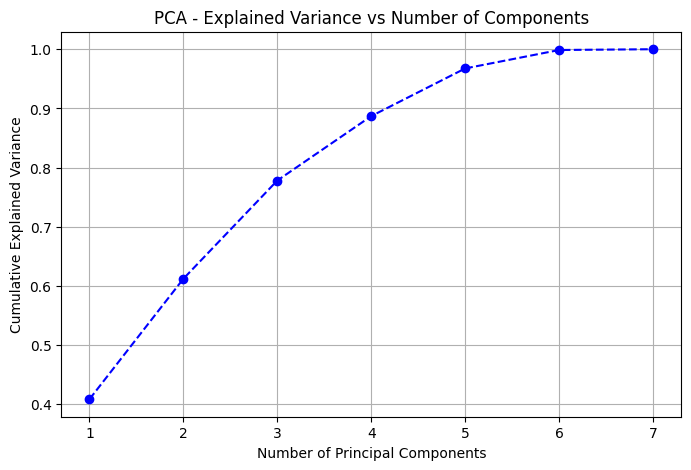

🔍 Number of principal components selected for 95% variance: 5
✅ Shape of transformed dataset: (1675, 5)


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- STEP 1: Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- STEP 2: Standardize features (PCA requires scaling) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 3: Apply PCA ---
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- STEP 4: Plot explained variance ratio ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Number of Components")
plt.grid(True)
plt.show()

# --- STEP 5: Select number of components for threshold ---
variance_threshold = 0.95  # e.g., 95% explained variance
k = np.argmax(cumulative_variance >= variance_threshold) + 1

print(f"🔍 Number of principal components selected for {variance_threshold*100:.0f}% variance: {k}")

# --- STEP 6: Transform data using selected components ---
pca_k = PCA(n_components=k)
X_pca = pca_k.fit_transform(X_scaled)

print(f"✅ Shape of transformed dataset: {X_pca.shape}")

# Combine with target variable for final


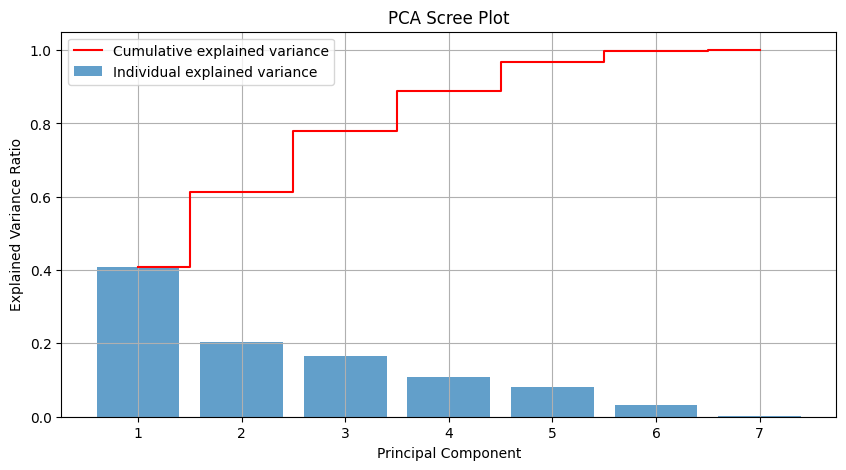

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Apply PCA ---
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- Scree plot ---
plt.figure(figsize=(10, 5))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    alpha=0.7,
    align="center",
    label="Individual explained variance"
)

plt.step(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    where="mid",
    color="red",
    label="Cumulative explained variance"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# --- Select components for threshold


🔍 Number of principal components selected for 95% variance: 5


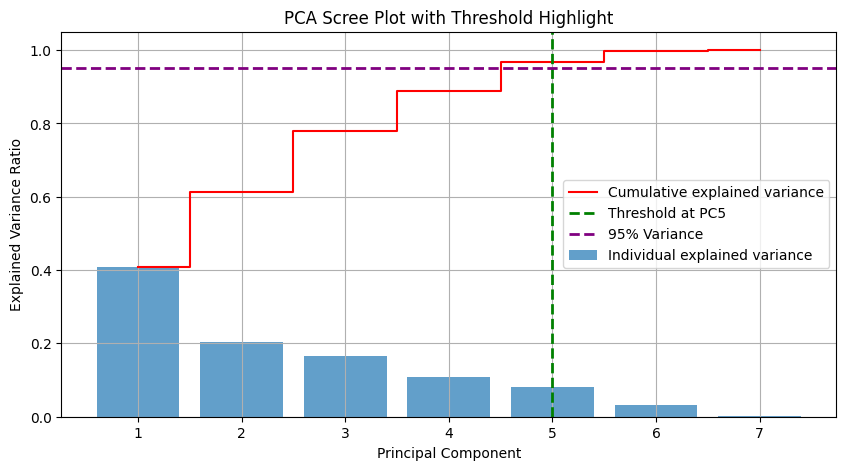

✅ Shape of transformed dataset: (1675, 5)


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Apply PCA ---
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- Select components for threshold ---
variance_threshold = 0.95
k = np.argmax(cumulative_variance >= variance_threshold) + 1

print(f"🔍 Number of principal components selected for {variance_threshold*100:.0f}% variance: {k}")

# --- Scree plot with threshold highlight ---
plt.figure(figsize=(10, 5))

# Bar plot for individual explained variance
plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    alpha=0.7,
    align="center",
    label="Individual explained variance"
)

# Step plot for cumulative variance
plt.step(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    where="mid",
    color="red",
    label="Cumulative explained variance"
)

# Highlight threshold point
plt.axvline(x=k, color="green", linestyle="--", linewidth=2, label=f"Threshold at PC{k}")
plt.axhline(y=variance_threshold, color="purple", linestyle="--", linewidth=2, label=f"{variance_threshold*100:.0f}% Variance")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot with Threshold Highlight")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# --- Transform dataset ---
pca_k = PCA(n_components=k)
X_pca = pca_k.fit_transform(X_scaled)

print(f"✅ Shape of transformed dataset: {X_pca.shape}")

# Save transformed dataset
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(k)])
pca_df["y"] = y.values
pca_df.to_excel("pca_selected_features.xlsx", index=False)


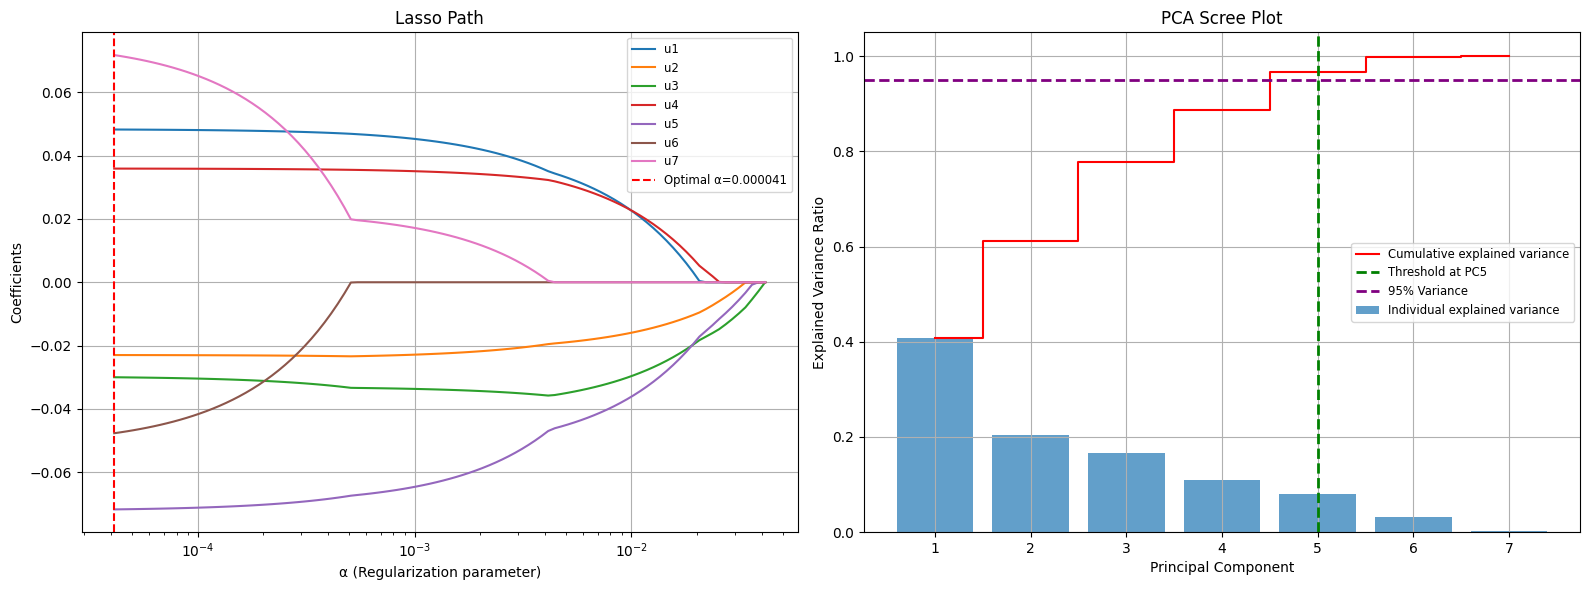

🔍 Number of principal components selected for 95% variance: 5


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")

if "y" not in train_df.columns:
    raise ValueError("Column 'y' not found in the data")

X = train_df.drop(columns=["y"])
y = train_df["y"]

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= LASSO PATH =================
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y)

# ================= PCA =================
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
variance_threshold = 0.95
k = np.argmax(cumulative_variance >= variance_threshold) + 1

# ================= PLOT =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Lasso coefficient path plot
for i in range(coefs_lasso.shape[0]):
    ax1.plot(alphas_lasso, coefs_lasso[i], label=X.columns[i])
ax1.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f"Optimal α={lasso_cv.alpha_:.6f}")
ax1.set_xscale('log')
ax1.set_xlabel("α (Regularization parameter)")
ax1.set_ylabel("Coefficients")
ax1.set_title("Lasso Path")
ax1.legend(fontsize="small")
ax1.grid(True)

# PCA scree plot
ax2.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align="center", label="Individual explained variance")
ax2.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where="mid", color="red", label="Cumulative explained variance")
ax2.axvline(x=k, color="green", linestyle="--", linewidth=2, label=f"Threshold at PC{k}")
ax2.axhline(y=variance_threshold, color="purple", linestyle="--", linewidth=2, label=f"{variance_threshold*100:.0f}% Variance")
ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Explained Variance Ratio")
ax2.set_title("PCA Scree Plot")
ax2.legend(loc="best", fontsize="small")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"🔍 Number of principal components selected for {variance_threshold*100:.0f}% variance: {k}")


✅ Selected features (Forward Selection): ['u3', 'u5', 'u1', 'u4', 'u2', 'u6']
First-order model: MSE = 0.0197, R² = 0.2349
Second-order model: MSE = 0.0159, R² = 0.3827


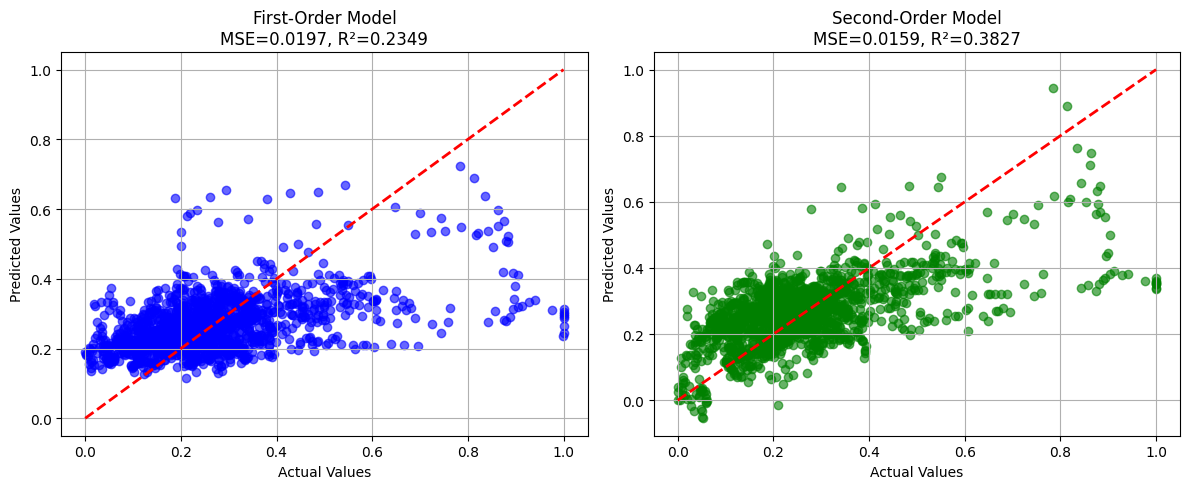

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= CORRELATION FILTERING =================
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
X = X.drop(columns=to_drop)

# ================= FORWARD SELECTION =================
selected_features_forward = []
remaining_features = list(X.columns)
current_aic = np.inf
improvement_threshold = 1e-4

def compute_aic(n, sse, num_params):
    return n * np.log(sse / n) + 2 * num_params

while remaining_features:
    best_feature = None
    best_aic = current_aic
    for feature in remaining_features:
        trial_features = selected_features_forward + [feature]
        model = LinearRegression()
        model.fit(X[trial_features], y)
        predictions = model.predict(X[trial_features])
        sse = mean_squared_error(y, predictions) * len(y)
        aic = compute_aic(len(y), sse, len(trial_features) + 1)
        if aic < best_aic:
            best_aic = aic
            best_feature = feature
    improvement = current_aic - best_aic
    if best_feature is not None and improvement > improvement_threshold:
        selected_features_forward.append(best_feature)
        remaining_features.remove(best_feature)
        current_aic = best_aic
    else:
        break

print("✅ Selected features (Forward Selection):", selected_features_forward)

# ================= MODEL BUILDING =================
X_selected = X[selected_features_forward]

# First-order model
model1 = LinearRegression()
model1.fit(X_selected, y)
y_pred1 = model1.predict(X_selected)
mse1 = mean_squared_error(y, y_pred1)
r2_1 = r2_score(y, y_pred1)

# Second-order model (squared + interactions)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_selected)
model2 = LinearRegression()
model2.fit(X_poly, y)
y_pred2 = model2.predict(X_poly)
mse2 = mean_squared_error(y, y_pred2)
r2_2 = r2_score(y, y_pred2)

# ================= RESULTS =================
print(f"First-order model: MSE = {mse1:.4f}, R² = {r2_1:.4f}")
print(f"Second-order model: MSE = {mse2:.4f}, R² = {r2_2:.4f}")

# ================= PLOTS =================
plt.figure(figsize=(12, 5))

# First-order predicted vs actual
plt.subplot(1, 2, 1)
plt.scatter(y, y_pred1, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"First-Order Model\nMSE={mse1:.4f}, R²={r2_1:.4f}")
plt.grid(True)

# Second-order predicted vs actual
plt.subplot(1, 2, 2)
plt.scatter(y, y_pred2, color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Second-Order Model\nMSE={mse2:.4f}, R²={r2_2:.4f}")
plt.grid(True)

plt.tight_layout()
plt.show()


In [47]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= CORRELATION FILTERING =================
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)
X = X.drop(columns=to_drop)

# ================= FORWARD SELECTION =================
selected_features_forward = []
remaining_features = list(X.columns)
current_aic = np.inf
improvement_threshold = 1e-4

def compute_aic(n, sse, num_params):
    return n * np.log(sse / n) + 2 * num_params

while remaining_features:
    best_feature = None
    best_aic = current_aic
    for feature in remaining_features:
        trial_features = selected_features_forward + [feature]
        model = LinearRegression()
        model.fit(X[trial_features], y)
        predictions = model.predict(X[trial_features])
        sse = mean_squared_error(y, predictions) * len(y)
        aic = compute_aic(len(y), sse, len(trial_features) + 1)
        if aic < best_aic:
            best_aic = aic
            best_feature = feature
    improvement = current_aic - best_aic
    if best_feature is not None and improvement > improvement_threshold:
        selected_features_forward.append(best_feature)
        remaining_features.remove(best_feature)
        current_aic = best_aic
    else:
        break

print("✅ Selected features (Forward Selection):", selected_features_forward)

# ================= MODEL BUILDING =================
results = []

def build_models(X_data, feature_names):
    # First-order model
    model1 = LinearRegression()
    model1.fit(X_data, y)
    y_pred1 = model1.predict(X_data)
    mse1 = mean_squared_error(y, y_pred1)
    r2_1 = r2_score(y, y_pred1)

    # Second-order model (squared + interaction terms)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_data)
    model2 = LinearRegression()
    model2.fit(X_poly, y)
    y_pred2 = model2.predict(X_poly)
    mse2 = mean_squared_error(y, y_pred2)
    r2_2 = r2_score(y, y_pred2)

    results.append({
        "Method": "Forward Selection",
        "Features": feature_names,
        "First-Order MSE": mse1,
        "First-Order R2": r2_1,
        "Second-Order MSE": mse2,
        "Second-Order R2": r2_2
    })

# Build models for Forward Selection features
build_models(X[selected_features_forward], selected_features_forward)

# ================= RESULTS =================
results_df = pd.DataFrame(results)
print("📊 Model Performance (Forward Selection):")
print(results_df)

# Save results
results_df.to_excel("forward_selection_model_results.xlsx", index=False)


🚫 Dropped due to high correlation: ['u7']
✅ Selected features (Forward Selection): ['u3', 'u5', 'u1', 'u4', 'u2', 'u6']
📊 Model Performance (Forward Selection):
              Method                  Features  First-Order MSE  \
0  Forward Selection  [u3, u5, u1, u4, u2, u6]         0.019738   

   First-Order R2  Second-Order MSE  Second-Order R2  
0        0.234895          0.015925         0.382728  


✅ Selected features (Forward Selection): ['u3', 'u5', 'u1', 'u4', 'u2', 'u7', 'u6']

📊 Forward Selection Model Comparison:
                            Model        SSE        R2          AIC  \
0   First-Order Forward Selection  32.894032  0.238775 -6569.214308   
1  Second-Order Forward Selection  25.892481  0.400803 -6914.106489   

           BIC  
0 -6531.249329  
1 -6724.281593  
✅ Forward selection comparison saved to 'forward_selection_model_comparison.xlsx'


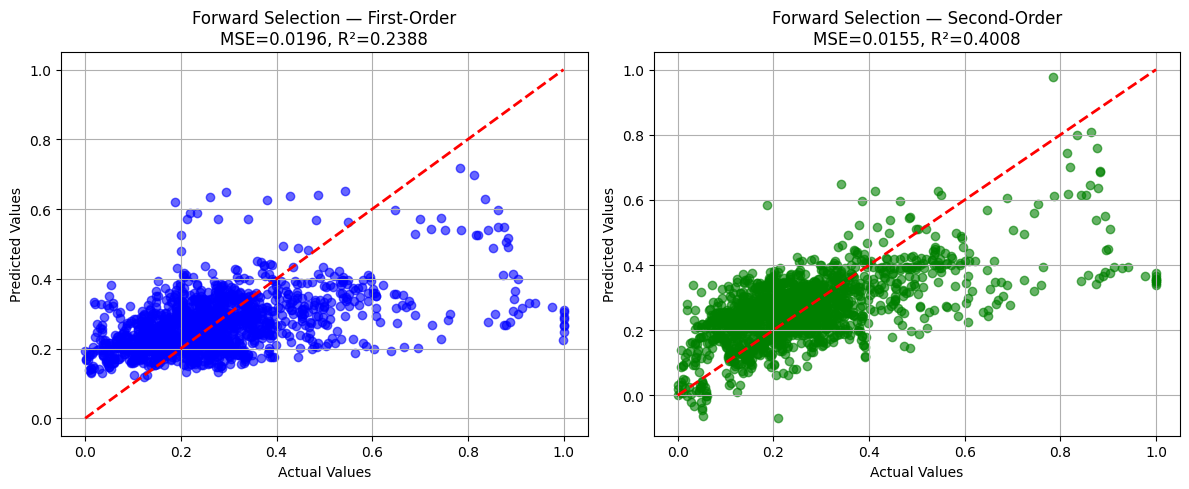

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= STANDARDIZE FEATURES =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# ================= FORWARD SELECTION =================
def forward_selection(X, y, max_features=None):
    remaining_features = list(X.columns)
    selected_features = []
    best_score = -np.inf
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    while remaining_features and (max_features is None or len(selected_features) < max_features):
        scores_with_candidates = []
        for candidate in remaining_features:
            features_to_test = selected_features + [candidate]
            model = LinearRegression()
            score = cross_val_score(model, X[features_to_test], y, cv=kf, scoring="r2").mean()
            scores_with_candidates.append((score, candidate))

        scores_with_candidates.sort(reverse=True)
        best_new_score, best_candidate = scores_with_candidates[0]

        if best_new_score > best_score:
            best_score = best_new_score
            selected_features.append(best_candidate)
            remaining_features.remove(best_candidate)
        else:
            break

    return selected_features

selected_features = forward_selection(X_scaled_df, y)
print(f"✅ Selected features (Forward Selection): {selected_features}")

# ================= MODEL BUILDING =================
X_selected = X_scaled_df[selected_features].values

# First-order model
model1 = LinearRegression()
model1.fit(X_selected, y)
y_pred1 = model1.predict(X_selected)
mse1 = mean_squared_error(y, y_pred1)
r2_1 = r2_score(y, y_pred1)

# Second-order model
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_selected)
model2 = LinearRegression()
model2.fit(X_poly, y)
y_pred2 = model2.predict(X_poly)
mse2 = mean_squared_error(y, y_pred2)
r2_2 = r2_score(y, y_pred2)

# ================= MODEL COMPARISON =================
def compute_aic_bic(y_true, y_pred, num_params):
    residual = y_true - y_pred
    sse = np.sum(residual ** 2)
    n = len(y_true)
    aic = n * np.log(sse / n) + 2 * num_params
    bic = n * np.log(sse / n) + np.log(n) * num_params
    return sse, aic, bic

num_params1 = X_selected.shape[1]
num_params2 = X_poly.shape[1]

sse1, aic1, bic1 = compute_aic_bic(y, y_pred1, num_params1)
sse2, aic2, bic2 = compute_aic_bic(y, y_pred2, num_params2)

comparison_results = pd.DataFrame({
    "Model": ["First-Order Forward Selection", "Second-Order Forward Selection"],
    "SSE": [sse1, sse2],
    "R2": [r2_1, r2_2],
    "AIC": [aic1, aic2],
    "BIC": [bic1, bic2]
})

print("\n📊 Forward Selection Model Comparison:")
print(comparison_results)

comparison_results.to_excel("forward_selection_model_comparison.xlsx", index=False)
print("✅ Forward selection comparison saved to 'forward_selection_model_comparison.xlsx'")

# ================= PLOTS =================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred1, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Forward Selection — First-Order\nMSE={mse1:.4f}, R²={r2_1:.4f}")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred2, color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Forward Selection — Second-Order\nMSE={mse2:.4f}, R²={r2_2:.4f}")
plt.grid(True)

plt.tight_layout()
plt.show()


🚫 Dropped due to high correlation: ['u7']
✅ Selected features (Forward Selection): ['u3', 'u5', 'u1', 'u4', 'u2', 'u6']
✅ Selected features (Lasso): ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']
✅ PCA selected components: PC1–PC5


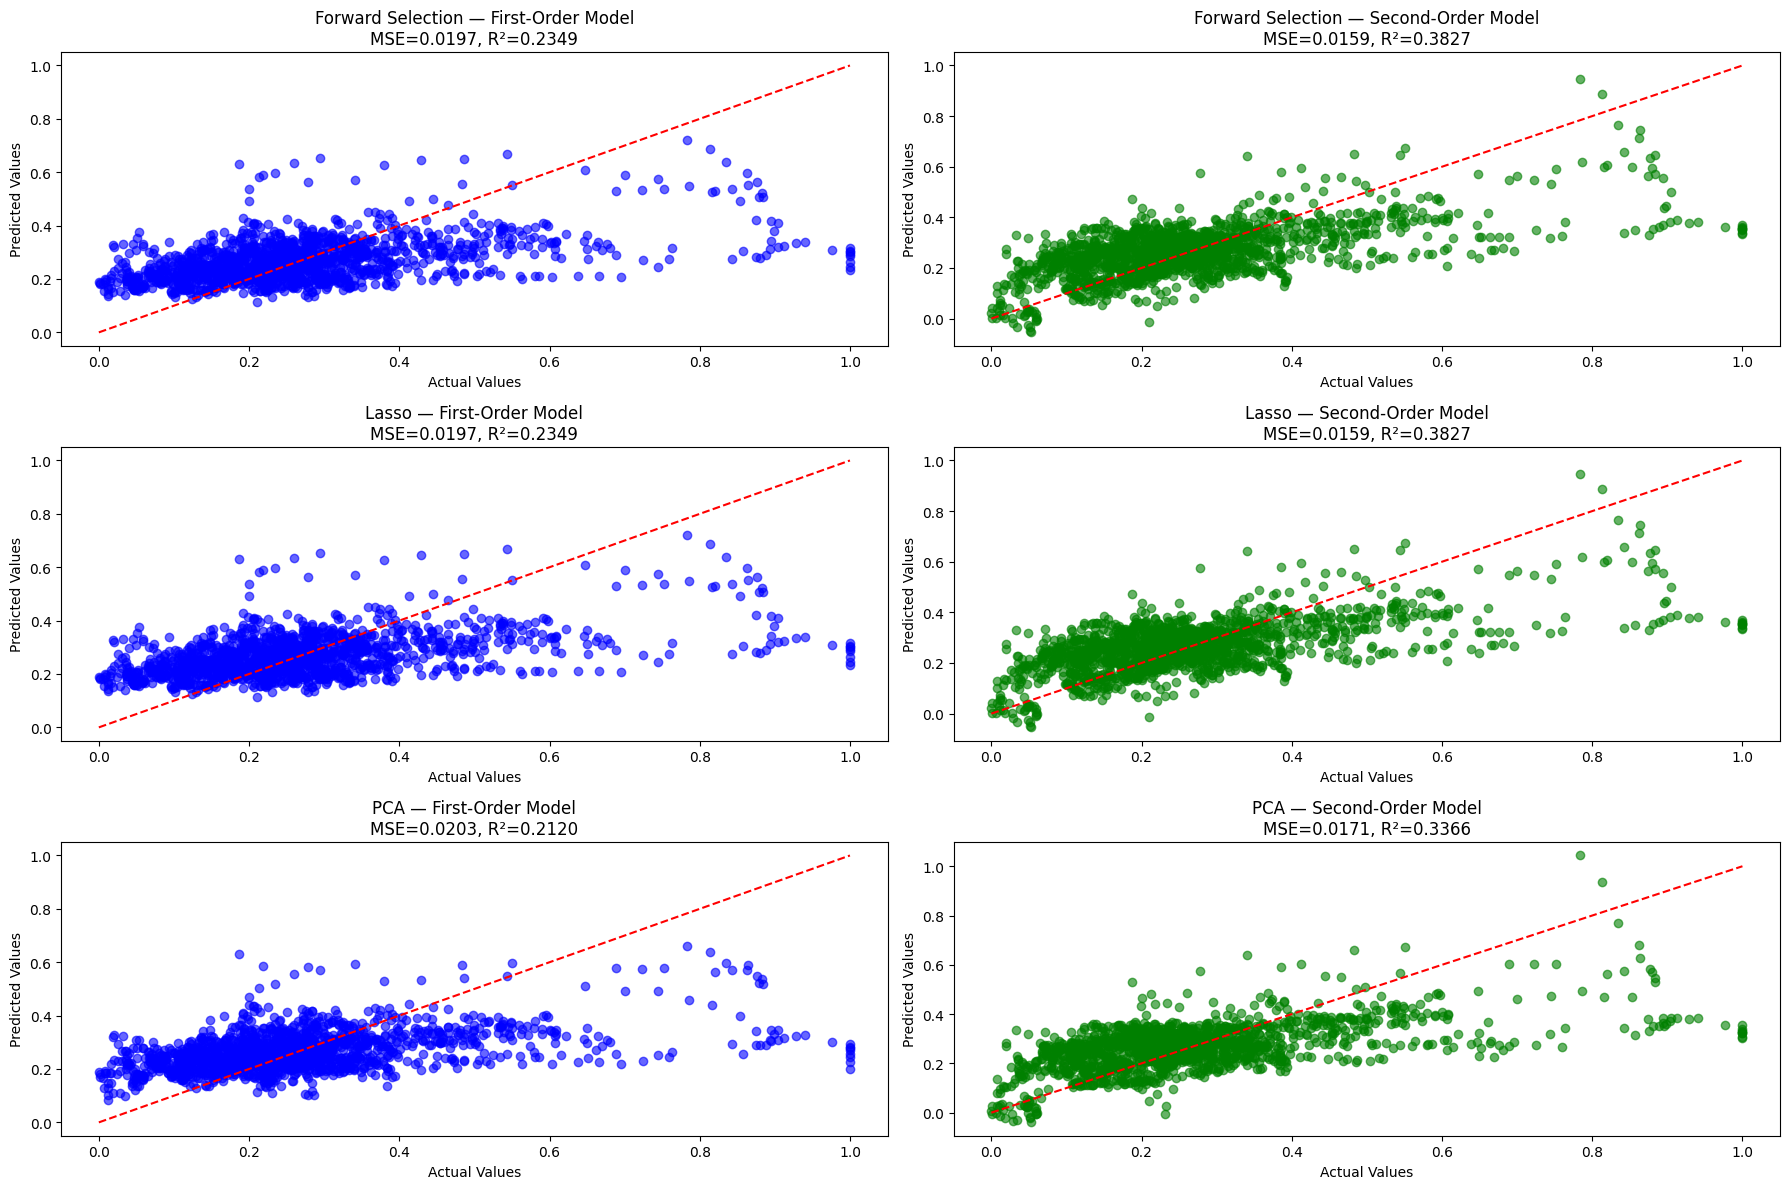

📊 Regression Model Performance Summary:
              Method                   Features  First-Order MSE  \
0  Forward Selection   [u3, u5, u1, u4, u2, u6]         0.019738   
1              Lasso   [u1, u2, u3, u4, u5, u6]         0.019738   
2                PCA  [PC1, PC2, PC3, PC4, PC5]         0.020329   

   First-Order R2  Second-Order MSE  Second-Order R2  
0        0.234895          0.015925         0.382728  
1        0.234895          0.015925         0.382728  
2        0.212014          0.017115         0.336584  


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from itertools import combinations

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= CORRELATION FILTERING =================
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("🚫 Dropped due to high correlation:", to_drop)
X = X.drop(columns=to_drop)

# ================= FORWARD SELECTION =================
selected_features_forward = []
remaining_features = list(X.columns)
current_aic = np.inf
improvement_threshold = 1e-4

def compute_aic(n, sse, num_params):
    return n * np.log(sse / n) + 2 * num_params

while remaining_features:
    best_feature = None
    best_aic = current_aic
    for feature in remaining_features:
        trial_features = selected_features_forward + [feature]
        model = LinearRegression()
        model.fit(X[trial_features], y)
        predictions = model.predict(X[trial_features])
        sse = mean_squared_error(y, predictions) * len(y)
        aic = compute_aic(len(y), sse, len(trial_features) + 1)
        if aic < best_aic:
            best_aic = aic
            best_feature = feature
    improvement = current_aic - best_aic
    if best_feature is not None and improvement > improvement_threshold:
        selected_features_forward.append(best_feature)
        remaining_features.remove(best_feature)
        current_aic = best_aic
    else:
        break

print("✅ Selected features (Forward Selection):", selected_features_forward)

# ================= LASSO =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)
coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features_lasso = coef[coef != 0].index.tolist()
print("✅ Selected features (Lasso):", selected_features_lasso)

# ================= PCA =================
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
variance_threshold = 0.95
k = np.argmax(cumulative_variance >= variance_threshold) + 1
pca_k = PCA(n_components=k)
X_pca = pca_k.fit_transform(X_scaled)
print(f"✅ PCA selected components: PC1–PC{k}")

# ================= MODEL BUILDING =================
methods = [
    ("Forward Selection", X[selected_features_forward], selected_features_forward),
    ("Lasso", X[selected_features_lasso], selected_features_lasso),
    ("PCA", X_pca, [f"PC{i+1}" for i in range(k)])
]

results = []

plt.figure(figsize=(18, 12))

for i, (method_name, X_data, feature_names) in enumerate(methods):
    # First-order model
    model1 = LinearRegression()
    model1.fit(X_data, y)
    y_pred1 = model1.predict(X_data)
    mse1 = mean_squared_error(y, y_pred1)
    r2_1 = r2_score(y, y_pred1)

    # Second-order model
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_data)
    model2 = LinearRegression()
    model2.fit(X_poly, y)
    y_pred2 = model2.predict(X_poly)
    mse2 = mean_squared_error(y, y_pred2)
    r2_2 = r2_score(y, y_pred2)

    results.append({
        "Method": method_name,
        "Features": feature_names,
        "First-Order MSE": mse1,
        "First-Order R2": r2_1,
        "Second-Order MSE": mse2,
        "Second-Order R2": r2_2
    })

    # PLOTS: Predicted vs Actual
    plt.subplot(3, 2, i*2+1)
    plt.scatter(y, y_pred1, color="blue", alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{method_name} — First-Order Model\nMSE={mse1:.4f}, R²={r2_1:.4f}")

    plt.subplot(3, 2, i*2+2)
    plt.scatter(y, y_pred2, color="green", alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{method_name} — Second-Order Model\nMSE={mse2:.4f}, R²={r2_2:.4f}")

plt.tight_layout()
plt.show()

# ================= SUMMARY =================
results_df = pd.DataFrame(results)
print("📊 Regression Model Performance Summary:")
print(results_df)

results_df.to_excel("model_building_comparison.xlsx", index=False)


✅ Optimal alpha (λ): 4.1297160670965574e-05
✅ Selected features by Lasso: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7']
First-order model: MSE = 0.0196, R² = 0.2388
Second-order model: MSE = 0.0155, R² = 0.4008


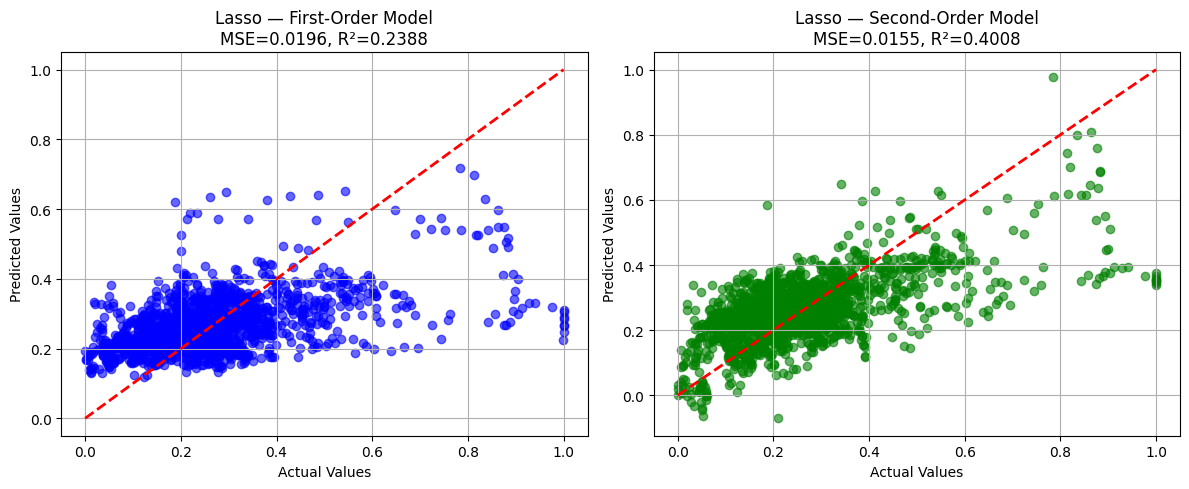

📊 Lasso model results saved to 'lasso_model_results.xlsx'


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= STANDARDIZE FEATURES =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= LASSO FEATURE SELECTION =================
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

# Coefficients from Lasso
coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features_lasso = coef[coef != 0].index.tolist()

print("✅ Optimal alpha (λ):", lasso_cv.alpha_)
print("✅ Selected features by Lasso:", selected_features_lasso)

# ================= MODEL BUILDING =================
X_selected = X[selected_features_lasso]

# First-order model
model1 = LinearRegression()
model1.fit(X_selected, y)
y_pred1 = model1.predict(X_selected)
mse1 = mean_squared_error(y, y_pred1)
r2_1 = r2_score(y, y_pred1)

# Second-order model (squared + interactions)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_selected)
model2 = LinearRegression()
model2.fit(X_poly, y)
y_pred2 = model2.predict(X_poly)
mse2 = mean_squared_error(y, y_pred2)
r2_2 = r2_score(y, y_pred2)

# ================= RESULTS =================
print(f"First-order model: MSE = {mse1:.4f}, R² = {r2_1:.4f}")
print(f"Second-order model: MSE = {mse2:.4f}, R² = {r2_2:.4f}")

# ================= PLOTS =================
plt.figure(figsize=(12, 5))

# First-order predicted vs actual
plt.subplot(1, 2, 1)
plt.scatter(y, y_pred1, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Lasso — First-Order Model\nMSE={mse1:.4f}, R²={r2_1:.4f}")
plt.grid(True)

# Second-order predicted vs actual
plt.subplot(1, 2, 2)
plt.scatter(y, y_pred2, color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Lasso — Second-Order Model\nMSE={mse2:.4f}, R²={r2_2:.4f}")
plt.grid(True)

plt.tight_layout()
plt.show()

# ================= SAVE RESULTS =================
results = {
    "Method": "Lasso Regression",
    "Alpha": lasso_cv.alpha_,
    "Selected Features": selected_features_lasso,
    "First-Order MSE": mse1,
    "First-Order R2": r2_1,
    "Second-Order MSE": mse2,
    "Second-Order R2": r2_2
}

results_df = pd.DataFrame([results])
results_df.to_excel("lasso_model_results.xlsx", index=False)
print("📊 Lasso model results saved to 'lasso_model_results.xlsx'")


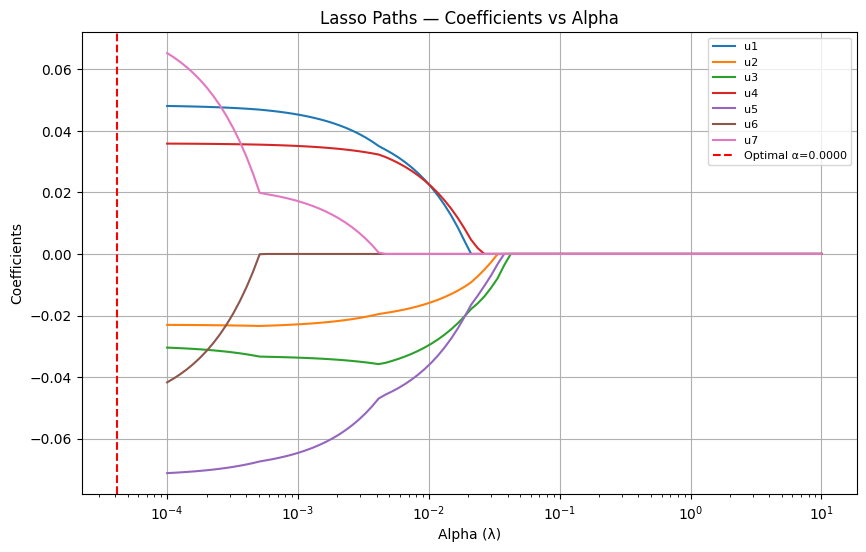

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Range of alpha values for Lasso path
alphas = np.logspace(-4, 1, 100)
coefs = []

# Fit Lasso for each alpha
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)  # <-- fixed this line

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=X.columns[i])

plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficients")
plt.title("Lasso Paths — Coefficients vs Alpha")
plt.xscale("log")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label=f"Optimal α={lasso_cv.alpha_:.4f}")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()


✅ Optimal Lasso alpha (λ): 0.0001

📊 Lasso Regression Model Comparison:
                Model        SSE        R2          AIC          BIC
0   First-Order Lasso  32.897707  0.238690 -6569.027208 -6531.062229
1  Second-Order Lasso  26.015278  0.397961 -6910.181455 -6731.203696
✅ Lasso regression comparison saved to 'lasso_regression_comparison.xlsx'


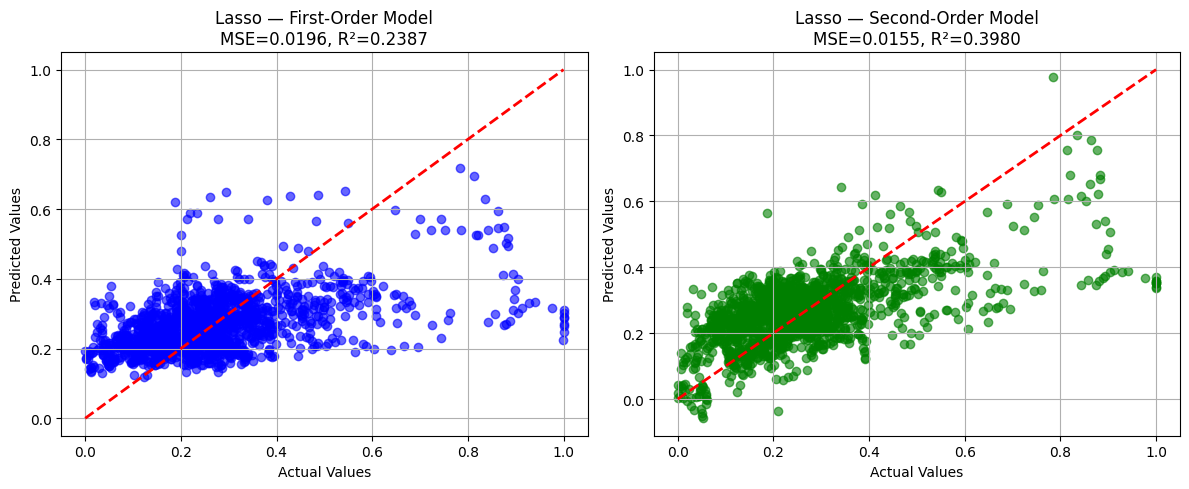

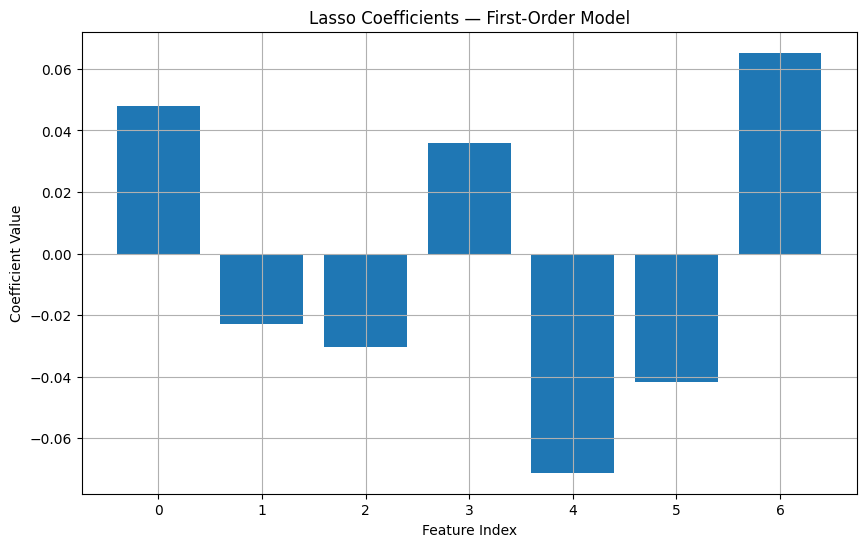

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= STANDARDIZE FEATURES =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= LASSO REGRESSION =================
alphas = np.logspace(-4, 1, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000)
lasso_cv.fit(X_scaled, y)

print(f"✅ Optimal Lasso alpha (λ): {lasso_cv.alpha_}")

# ================= MODEL BUILDING =================
# First-order Lasso model
model1 = Lasso(alpha=lasso_cv.alpha_, max_iter=5000)
model1.fit(X_scaled, y)
y_pred1 = model1.predict(X_scaled)
mse1 = mean_squared_error(y, y_pred1)
r2_1 = r2_score(y, y_pred1)

# Second-order Lasso model
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)
model2 = Lasso(alpha=lasso_cv.alpha_, max_iter=5000)
model2.fit(X_poly, y)
y_pred2 = model2.predict(X_poly)
mse2 = mean_squared_error(y, y_pred2)
r2_2 = r2_score(y, y_pred2)

# ================= MODEL COMPARISON =================
def compute_aic_bic(y_true, y_pred, num_params):
    residual = y_true - y_pred
    sse = np.sum(residual ** 2)
    n = len(y_true)
    aic = n * np.log(sse / n) + 2 * num_params
    bic = n * np.log(sse / n) + np.log(n) * num_params
    return sse, aic, bic

num_params1 = np.sum(model1.coef_ != 0)  # Only count non-zero coefficients
num_params2 = np.sum(model2.coef_ != 0)

sse1, aic1, bic1 = compute_aic_bic(y, y_pred1, num_params1)
sse2, aic2, bic2 = compute_aic_bic(y, y_pred2, num_params2)

comparison_results = pd.DataFrame({
    "Model": ["First-Order Lasso", "Second-Order Lasso"],
    "SSE": [sse1, sse2],
    "R2": [r2_1, r2_2],
    "AIC": [aic1, aic2],
    "BIC": [bic1, bic2]
})

print("\n📊 Lasso Regression Model Comparison:")
print(comparison_results)

comparison_results.to_excel("lasso_regression_comparison.xlsx", index=False)
print("✅ Lasso regression comparison saved to 'lasso_regression_comparison.xlsx'")

# ================= PLOTS =================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred1, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Lasso — First-Order Model\nMSE={mse1:.4f}, R²={r2_1:.4f}")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred2, color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Lasso — Second-Order Model\nMSE={mse2:.4f}, R²={r2_2:.4f}")
plt.grid(True)

plt.tight_layout()
plt.show()

# ================= COEFFICIENT PLOT =================
plt.figure(figsize=(10, 6))
plt.bar(range(len(model1.coef_)), model1.coef_)
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficients — First-Order Model")
plt.grid(True)
plt.show()


✅ Number of PCs selected to explain ≥95% variance: 5


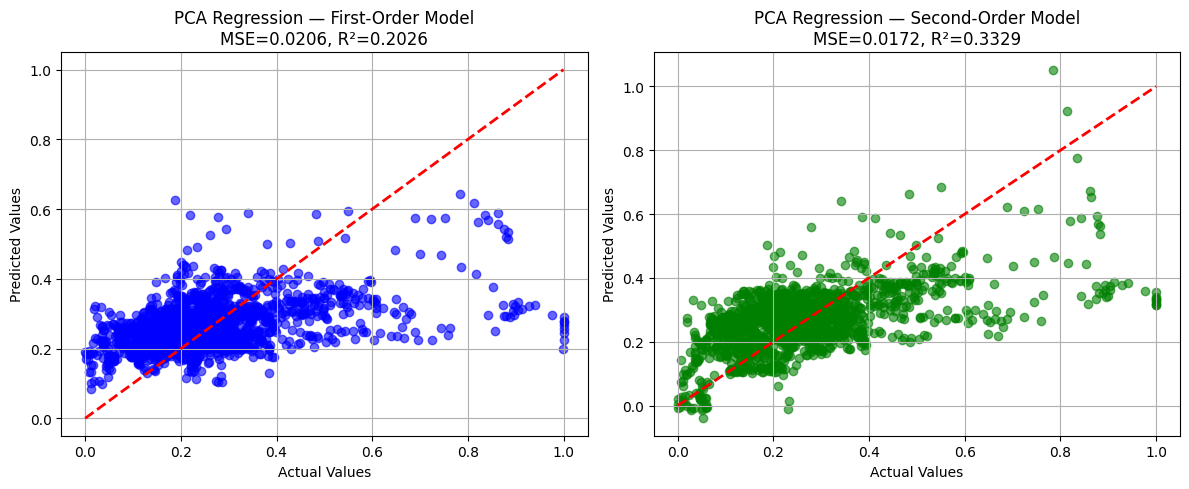

📊 PCA Regression Model Summary:
           Method  Number of PCs  First-Order MSE  First-Order R2  \
0  PCA Regression              5         0.020571        0.202603   

   Second-Order MSE  Second-Order R2  
0          0.017209         0.332931  
📊 Results saved to 'pca_regression_results.xlsx'


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= STANDARDIZE FEATURES =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= PCA =================
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Choose k components that explain ≥95% variance
variance_threshold = 0.95
k = np.argmax(cumulative_variance >= variance_threshold) + 1

print(f"✅ Number of PCs selected to explain ≥{variance_threshold*100:.0f}% variance: {k}")

pca_k = PCA(n_components=k)
X_pca = pca_k.fit_transform(X_scaled)

# ================= MODEL BUILDING =================
results = []

def build_pca_models(X_data, method_name):
    # First-order model
    model1 = LinearRegression()
    model1.fit(X_data, y)
    y_pred1 = model1.predict(X_data)
    mse1 = mean_squared_error(y, y_pred1)
    r2_1 = r2_score(y, y_pred1)

    # Second-order model
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_data)
    model2 = LinearRegression()
    model2.fit(X_poly, y)
    y_pred2 = model2.predict(X_poly)
    mse2 = mean_squared_error(y, y_pred2)
    r2_2 = r2_score(y, y_pred2)

    results.append({
        "Method": method_name,
        "Number of PCs": X_data.shape[1],
        "First-Order MSE": mse1,
        "First-Order R2": r2_1,
        "Second-Order MSE": mse2,
        "Second-Order R2": r2_2
    })

    # ================= PLOTS =================
    plt.figure(figsize=(12, 5))

    # First-order predicted vs actual
    plt.subplot(1, 2, 1)
    plt.scatter(y, y_pred1, color="blue", alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{method_name} — First-Order Model\nMSE={mse1:.4f}, R²={r2_1:.4f}")
    plt.grid(True)

    # Second-order predicted vs actual
    plt.subplot(1, 2, 2)
    plt.scatter(y, y_pred2, color="green", alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{method_name} — Second-Order Model\nMSE={mse2:.4f}, R²={r2_2:.4f}")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run PCA-based regression
build_pca_models(X_pca, "PCA Regression")

# ================= SUMMARY ==============
results_df = pd.DataFrame(results)
print("📊 PCA Regression Model Summary:")
print(results_df)

results_df.to_excel("pca_regression_results.xlsx", index=False)
print("📊 Results saved to 'pca_regression_results.xlsx'")


✅ Number of PCA components selected: 5

📊 PCA Regression Model Comparison:
                         Model        SSE        R2          AIC          BIC
0   First-Order PCA Regression  34.457108  0.202603 -6495.454010 -6468.336167
1  Second-Order PCA Regression  28.825361  0.332931 -6764.374008 -6655.902639
✅ PCA regression comparison saved to 'pca_regression_comparison.xlsx'


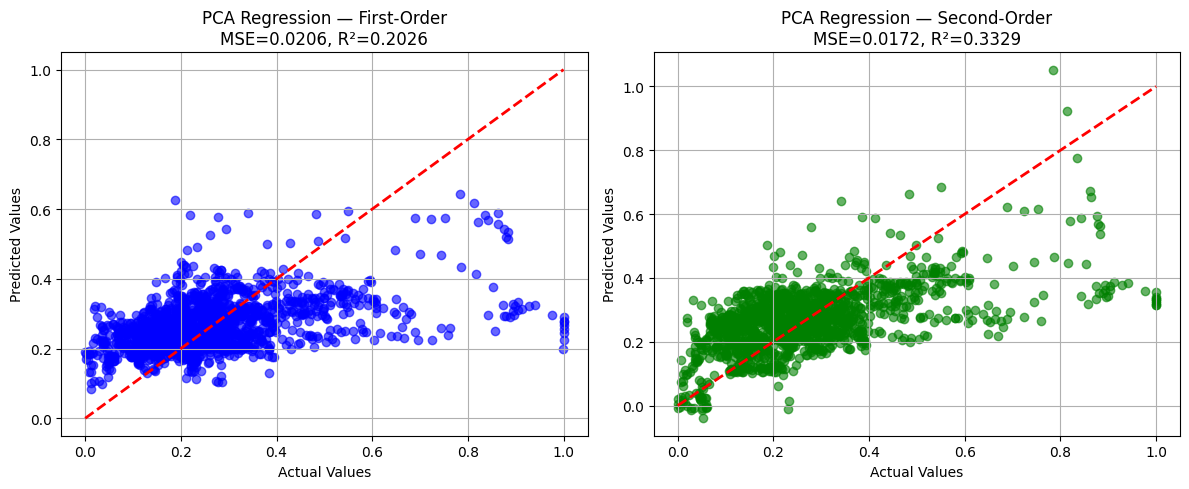

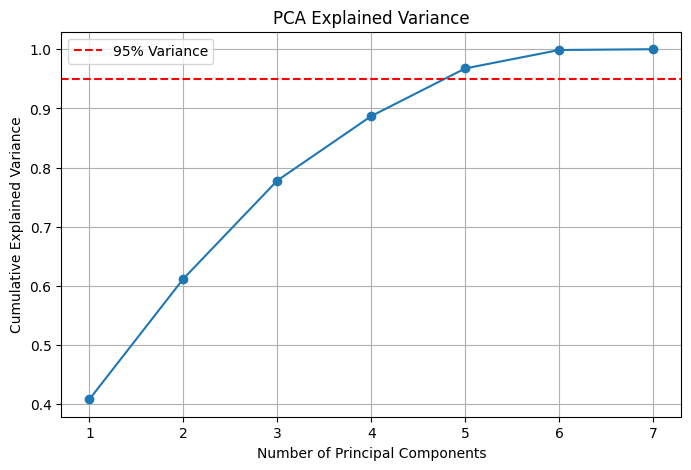

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= STANDARDIZE FEATURES =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= PCA =================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
k_components = np.argmax(explained_variance >= 0.95) + 1  # 95% variance

print(f"✅ Number of PCA components selected: {k_components}")

X_pca_reduced = X_pca[:, :k_components]

# ================= MODEL BUILDING =================
# First-order PCA regression
model1 = LinearRegression()
model1.fit(X_pca_reduced, y)
y_pred1 = model1.predict(X_pca_reduced)
mse1 = mean_squared_error(y, y_pred1)
r2_1 = r2_score(y, y_pred1)

# Second-order PCA regression
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_pca_reduced)
model2 = LinearRegression()
model2.fit(X_poly, y)
y_pred2 = model2.predict(X_poly)
mse2 = mean_squared_error(y, y_pred2)
r2_2 = r2_score(y, y_pred2)

# ================= MODEL COMPARISON =================
def compute_aic_bic(y_true, y_pred, num_params):
    residual = y_true - y_pred
    sse = np.sum(residual ** 2)
    n = len(y_true)
    aic = n * np.log(sse / n) + 2 * num_params
    bic = n * np.log(sse / n) + np.log(n) * num_params
    return sse, aic, bic

num_params1 = X_pca_reduced.shape[1]
num_params2 = X_poly.shape[1]

sse1, aic1, bic1 = compute_aic_bic(y, y_pred1, num_params1)
sse2, aic2, bic2 = compute_aic_bic(y, y_pred2, num_params2)

comparison_results = pd.DataFrame({
    "Model": ["First-Order PCA Regression", "Second-Order PCA Regression"],
    "SSE": [sse1, sse2],
    "R2": [r2_1, r2_2],
    "AIC": [aic1, aic2],
    "BIC": [bic1, bic2]
})

print("\n📊 PCA Regression Model Comparison:")
print(comparison_results)

comparison_results.to_excel("pca_regression_comparison.xlsx", index=False)
print("✅ PCA regression comparison saved to 'pca_regression_comparison.xlsx'")

# ================= PLOTS =================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred1, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"PCA Regression — First-Order\nMSE={mse1:.4f}, R²={r2_1:.4f}")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred2, color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"PCA Regression — Second-Order\nMSE={mse2:.4f}, R²={r2_2:.4f}")
plt.grid(True)

plt.tight_layout()
plt.show()

# ================= EXPLAINED VARIANCE PLOT =================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.legend()
plt.show()


✅ Optimal Ridge alpha (λ): 0.521400828799969
First-order Ridge model: MSE = 0.0196, R² = 0.2388
Second-order Ridge model: MSE = 0.0156, R² = 0.3966


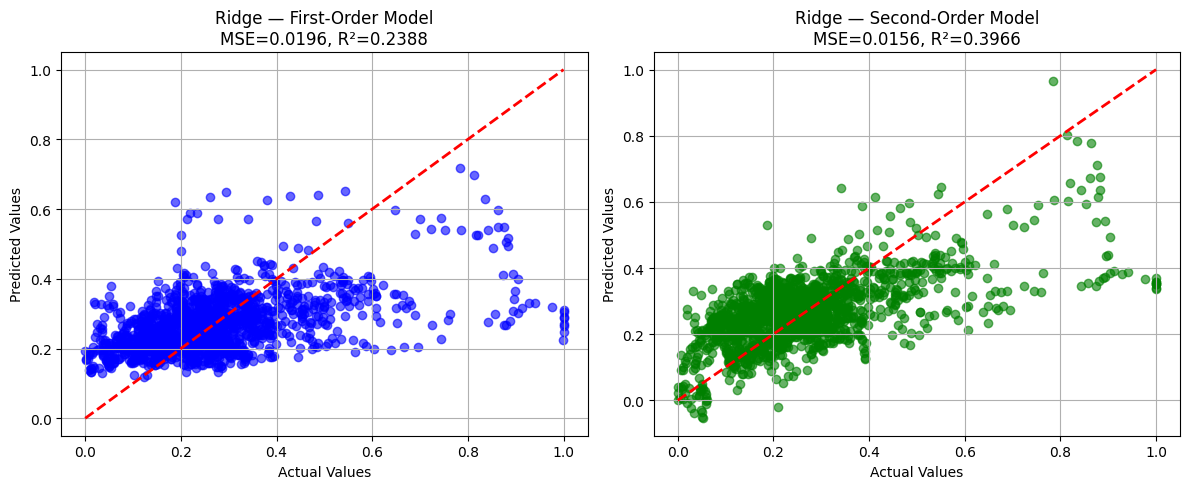

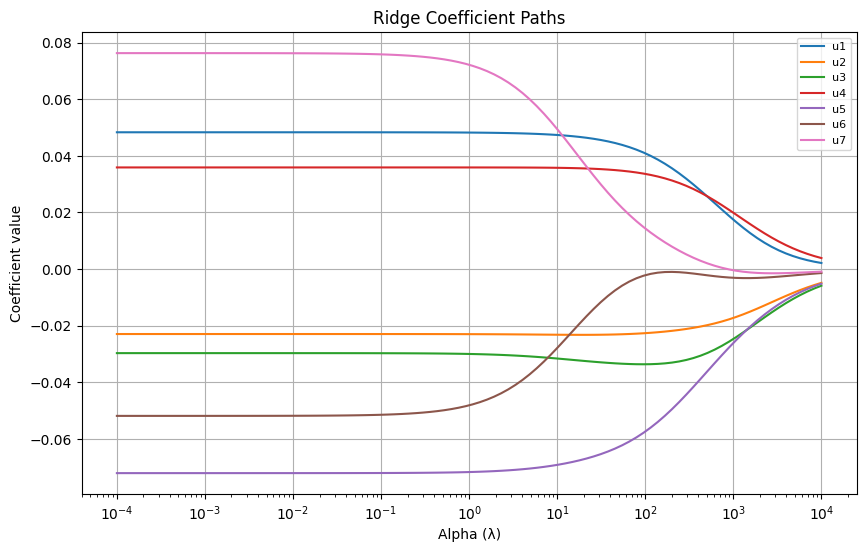

📊 Ridge regression results saved to 'ridge_regression_results.xlsx'


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# --- Load data ---
train_df = pd.read_excel("train_data_scaled.xlsx")
X = train_df.drop(columns=["y"])
y = train_df["y"]

# ================= STANDARDIZE FEATURES =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= RIDGE REGRESSION =================
alphas = np.logspace(-4, 4, 100)  # Range of alpha values
ridge_cv = RidgeCV(alphas=alphas, cv=5)  # Cross-validation for alpha
ridge_cv.fit(X_scaled, y)

print(f"✅ Optimal Ridge alpha (λ): {ridge_cv.alpha_}")

# ================= MODEL BUILDING =================
# First-order Ridge model
model1 = RidgeCV(alphas=alphas, cv=5)
model1.fit(X_scaled, y)
y_pred1 = model1.predict(X_scaled)
mse1 = mean_squared_error(y, y_pred1)
r2_1 = r2_score(y, y_pred1)

# Second-order Ridge model
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)
model2 = RidgeCV(alphas=alphas, cv=5)
model2.fit(X_poly, y)
y_pred2 = model2.predict(X_poly)
mse2 = mean_squared_error(y, y_pred2)
r2_2 = r2_score(y, y_pred2)

# ================= RESULTS =================
print(f"First-order Ridge model: MSE = {mse1:.4f}, R² = {r2_1:.4f}")
print(f"Second-order Ridge model: MSE = {mse2:.4f}, R² = {r2_2:.4f}")

# ================= PREDICTED VS ACTUAL PLOTS =================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred1, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Ridge — First-Order Model\nMSE={mse1:.4f}, R²={r2_1:.4f}")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred2, color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Ridge — Second-Order Model\nMSE={mse2:.4f}, R²={r2_2:.4f}")
plt.grid(True)

plt.tight_layout()
plt.show()

# ================= RIDGE COEFFICIENT PATH =================
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=X.columns[i])

plt.xscale("log")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Paths")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()

# ================= SAVE RESULTS =================
results = {
    "Method": "Bayesian Linear Regression (Ridge)",
    "Optimal Alpha": ridge_cv.alpha_,
    "First-Order MSE": mse1,
    "First-Order R2": r2_1,
    "Second-Order MSE": mse2,
    "Second-Order R2": r2_2
}

results_df = pd.DataFrame([results])
results_df.to_excel("ridge_regression_results.xlsx", index=False)
print("📊 Ridge regression results saved to 'ridge_regression_results.xlsx'")


In [65]:
def compute_aic_bic(y_true, y_pred, num_params):
    residual = y_true - y_pred
    sse = np.sum(residual ** 2)
    n = len(y_true)
    aic = n * np.log(sse / n) + 2 * num_params
    bic = n * np.log(sse / n) + np.log(n) * num_params
    return sse, aic, bic

# ================= MODEL COMPARISON =================
num_params1 = X_scaled.shape[1]  # number of features in first-order model
num_params2 = X_poly.shape[1]    # number of features in second-order model

sse1, aic1, bic1 = compute_aic_bic(y, y_pred1, num_params1)
sse2, aic2, bic2 = compute_aic_bic(y, y_pred2, num_params2)

comparison_results = pd.DataFrame({
    "Model": ["First-Order Ridge", "Second-Order Ridge"],
    "SSE": [sse1, sse2],
    "R2": [r2_1, r2_2],
    "AIC": [aic1, aic2],
    "BIC": [bic1, bic2]
})

print("\n📊 Model Comparison:")
print(comparison_results)

# Save comparison to Excel
comparison_results.to_excel("ridge_model_comparison.xlsx", index=False)
print("✅ Model comparison saved to 'ridge_model_comparison.xlsx'")



📊 Model Comparison:
                Model        SSE        R2          AIC          BIC
0   First-Order Ridge  32.894176  0.238772 -6569.206973 -6531.241994
1  Second-Order Ridge  26.074338  0.396595 -6902.383225 -6712.558330
✅ Model comparison saved to 'ridge_model_comparison.xlsx'
